# Pre-trained Encoder + JacobianODE — Lorenz (Loop Closure Sweep)

This notebook sweeps over **loop closure weight** values for the JacobianODE
trained on a pre-trained encoder's latent space.

**Pipeline:**
1. Load pre-trained encoder config from W&B
2. Build Hydra overrides (single source of truth for both local config and sweep command)
3. Check W&B for already-completed runs
4. Launch Hydra `--multirun` sweep via SLURM (each lambda value = one SLURM job)
5. Collect results from W&B, apply physics-informed model selection (C1/C2/C3)
6. Load the best model for downstream use

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import torch
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.encoder_only.pretrained import load_pretrained_encoder
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from hydra.utils import instantiate

torch.set_float32_matmul_precision('high')

In [20]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs"
ENCODER_SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoders"
WANDB_ENTITY = "JacobianODE"
# WANDB_PROJECT = None  # Auto-generated below from data class
WANDB_PROJECT = "Lorenz__PretrainedEncoderJacODE"

# ----------------------------------------------------------------
# Pre-trained encoder source (EDIT THESE)
# ----------------------------------------------------------------
# ENCODER_PROJECT = "JacobianODE/<YOUR_ENCODER_PROJECT>"  # e.g. "JacobianODE/Lorenz__EncoderOnly"
# ENCODER_RUN_ID = "<YOUR_RUN_ID>"                        # e.g. "abc12345"

ENCODER_PROJECT = "LorenzPartial_SEQ250BURN50K1D43__Encoder"
ENCODER_RUN_ID = "iu8cq3qx"

## 1. Settings

In [21]:
# ----------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------
# LAMBDA_LOOP_VALUES = [0.0, 0.001, 0.01, 0.1, 1.0]
LAMBDA_LOOP_VALUES = [0.001, 0.01, 0.1, 1.0, 10, 100]

FREEZE_ENCODER = True

In [23]:
# ----------------------------------------------------------------
# Load pre-trained encoder
# ----------------------------------------------------------------
adapter, encoder_cfg, encoder_run = load_pretrained_encoder(
    project=ENCODER_PROJECT,
    run_id=ENCODER_RUN_ID,
    save_dir=ENCODER_SAVE_DIR,
    freeze=FREEZE_ENCODER,
    verbose=True,
)

N_LATENT = adapter.n_latent
print(f"Encoder type:    {type(adapter.encoder).__name__}")
print(f"n_latent:        {N_LATENT}")
print(f"context_margin:  {adapter.context_margin}")
print(f"Frozen:          {FREEZE_ENCODER}")

No checkpoint for best epoch 23; using epoch=24-step=1250.ckpt instead.


Loading checkpoint epoch=24-step=1250.ckpt...
Encoder type:    SSMSequenceEncoder
n_latent:        10
context_margin:  0
Frozen:          True


## 2. Data Hyperparameters (from encoder config)

In [24]:
NUM_ICS = int(encoder_cfg.data.trajectory_params.num_ics)
N_PERIODS = int(encoder_cfg.data.trajectory_params.n_periods)
PTS_PER_PERIOD = int(encoder_cfg.data.trajectory_params.pts_per_period)
SEQ_LENGTH = int(encoder_cfg.data.train_test_params.seq_length)
OBS_NOISE = float(encoder_cfg.data.postprocessing.obs_noise)

delay_params = encoder_cfg.data.train_test_params.delay_embedding_params
OBSERVED_INDICES = list(delay_params.observed_indices) if delay_params.observed_indices != "all" else "all"
N_DELAYS = int(delay_params.get("n_delays", 1))
DELAY_SPACING = int(delay_params.get("delay_spacing", 1))

print(f"Data config (from encoder):")
print(f"  NUM_ICS={NUM_ICS}, N_PERIODS={N_PERIODS}, PTS_PER_PERIOD={PTS_PER_PERIOD}")
print(f"  SEQ_LENGTH={SEQ_LENGTH}, OBS_NOISE={OBS_NOISE}")
print(f"  OBSERVED_INDICES={OBSERVED_INDICES}, N_DELAYS={N_DELAYS}")

Data config (from encoder):
  NUM_ICS=32, N_PERIODS=12, PTS_PER_PERIOD=100
  SEQ_LENGTH=100, OBS_NOISE=0.05
  OBSERVED_INDICES=[0], N_DELAYS=43


## 3. JacobianODE Hyperparameters (fixed across sweep)

In [25]:
# ----------------------------------------------------------------
# JacobianODE integration
# ----------------------------------------------------------------
# PREDICTION_STEPS = 10
PREDICTION_STEPS = 30
TRAJ_INIT_STEPS = 15
INTERP_PTS = 4
INNER_N = 20
JAC_WINDOW_STRIDE = PREDICTION_STEPS  # non-overlapping

# ----------------------------------------------------------------
# Jacobian MLP architecture
# ----------------------------------------------------------------
# JAC_HIDDEN_DIM = [256, 512, 512]
# JAC_NUM_LAYERS = 3
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

# ----------------------------------------------------------------
# Fixed loss weights (loop_closure_weight is swept)
# ----------------------------------------------------------------
RECONSTRUCTION_LOSS_WEIGHT = 0.0 if FREEZE_ENCODER else 1.0
# LATENT_PREDICTION_LOSS_WEIGHT = 0.0
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
JAC_CONSISTENCY_WEIGHT = 0.0
FNN_WEIGHT = 0.0 if FREEZE_ENCODER else 0.001

# ----------------------------------------------------------------
# Training
# ----------------------------------------------------------------
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
LIMIT_TRAIN_BATCHES = 500
LIMIT_VAL_BATCHES = 50
ACCUMULATE_GRAD_BATCHES = 4
EARLY_STOPPING_PATIENCE = 5

## 4. Build Base Config

In [26]:
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '') if OBSERVED_INDICES != "all" else "all"

_enc = encoder_cfg.model.encoder

overrides = [
    # Model template
    "model=latent_ssm",
    # --- Encoder: propagate actual pretrained encoder architecture ---
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.d_model={int(_enc.get('d_model', 64))}",
    f"model.encoder.d_state={int(_enc.get('d_state', 64))}",
    f"model.encoder.n_layers={int(_enc.get('n_layers', 3))}",
    f"model.encoder.ffn_expand={int(_enc.get('ffn_expand', 2))}",
    f"model.encoder.r_min={float(_enc.get('r_min', 0.0))}",
    f"model.encoder.r_max={float(_enc.get('r_max', 0.99))}",
    f"model.encoder.dropout={float(_enc.get('dropout', 0.1))}",
    f"model.encoder.use_positional_encoding={bool(_enc.get('use_positional_encoding', True))}",
    f"model.encoder.positional_encoding_type={_enc.get('positional_encoding_type', 'sinusoidal')}",
    f"model.encoder.decoder_hidden={int(_enc.get('decoder_hidden', 128))}",
    f"model.encoder.decoder_layers={int(_enc.get('decoder_layers', 2))}",
    f"model.encoder.context_margin={adapter.context_margin}",
    f"model.prediction_steps={PREDICTION_STEPS}",
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",
    
    # Data (match encoder)
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",
    
    # Pretrained encoder
    f"pretrained_encoder.project={ENCODER_PROJECT}",
    f"pretrained_encoder.run_id={ENCODER_RUN_ID}",
    f"pretrained_encoder.save_dir={ENCODER_SAVE_DIR}",
    f"pretrained_encoder.freeze={FREEZE_ENCODER}",
    
    # Training
    f"training.batch_size={BATCH_SIZE}",
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",
    f"training.lightning.latent_prediction_loss_weight={LATENT_PREDICTION_LOSS_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT}",
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(config_name="pretrained_config", overrides=overrides)
cfg = initialize_config(cfg)

# Auto-generate project name
data_cls = cfg.data.flow._target_.split('.')[-1]
if WANDB_PROJECT is None:
    WANDB_PROJECT = f"{data_cls}__PretrainedEncoderJacODE"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")

W&B project: JacobianODE/Lorenz__PretrainedEncoderJacODE
Jacobian MLP: input_dim=10, output_dim=100


## 5. Generate Data (once, shared across sweep)

In [27]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [28]:
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor

cfg.data.postprocessing.mu = float(mu)
cfg.data.postprocessing.sigma = float(sigma)
cfg.data.postprocessing.noise_scale_factor = float(noise_scale_factor)

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
n_obs = trajs['train_trajs'].sequence.shape[-1]
n_dims = values.shape[-1]

print(f"\nn_obs = {n_obs}, n_dims = {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f} (C2 loop-closure threshold)")

Sequence Indices:   0%|          | 0/1058 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23276, 100, 43])
Validation dataset shape: torch.Size([7406, 100, 43])
Test dataset shape: torch.Size([3174, 100, 43])
Train trajectories dataset shape: torch.Size([22, 1158, 43])
Validation trajectories dataset shape: torch.Size([7, 1158, 43])
Test trajectories dataset shape: torch.Size([3, 1158, 43])

n_obs = 43, n_dims = 3
sqrt(n_dims) = 1.7321 (C2 loop-closure threshold)


## 6. Launch Sweep over `loop_closure_weight`

Uses Hydra `--multirun` with the SLURM launcher to submit one job per lambda
value in parallel. The entry point `run_pretrained_jacobians` loads the
pre-trained encoder from W&B inside each SLURM job.

The `overrides` list from Section 4 is the **single source of truth** — the
sweep command simply appends the swept parameter (comma-separated lambda values)
and W&B/SLURM settings.

In [29]:
# ----------------------------------------------------------------
# Check which lambda values already have completed runs on W&B
# ----------------------------------------------------------------
api = wandb.Api()
try:
    existing_runs = api.runs(WANDB_PROJECT_PATH)
    print(f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}")
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

already_run = []
remaining_lambdas = []
for lam in LAMBDA_LOOP_VALUES:
    matching = [
        run for run in existing_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and run.state == 'finished'
    ]
    if matching:
        already_run.append(lam)
    else:
        remaining_lambdas.append(lam)

print(f"\nAlready completed: {already_run}")
print(f"Remaining to run:  {remaining_lambdas}")

Found 6 total runs in JacobianODE/Lorenz__PretrainedEncoderJacODE

Already completed: [0.001, 0.01, 0.1, 1.0, 10, 100]
Remaining to run:  []


In [30]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
# Reuses `overrides` from Section 4 as the single source of truth.
# Only the three sweep-specific additions differ from the local config:
#   - loop_closure_weight  : the swept parameter (comma-separated for --multirun)
#   - wandb_entity/project : W&B logging target for the training jobs
#   - slurm=default        : SLURM launcher (not needed locally)

if remaining_lambdas:
    lambda_str = ",".join(str(v) for v in remaining_lambdas)

    sweep_overrides = overrides + [
        f"training.lightning.loop_closure_weight={lambda_str}",
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]

    sweep_cmd = (
        "python -m JacobianODE.jacobians.run_pretrained_jacobians --multirun "
        + " ".join(sweep_overrides)
    )

    print(f"Sweep command ({len(remaining_lambdas)} jobs):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


In [31]:
# Launch the sweep (submits SLURM jobs).
import subprocess
if sweep_cmd is not None:
    # !{sweep_cmd}
    subprocess.run(sweep_cmd, shell=True)
else:
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


## 7. Collect W&B Runs and Model Selection

### 7a. Collect Run IDs

In [32]:
api = wandb.Api()
all_runs = api.runs(WANDB_PROJECT_PATH)
print(f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}")

# Remove crashed/failed runs (pretrained encoder + JacobianODE)
def _is_pretrained_jac_run(run):
    return "pretrained_encoder" in run.config or (
        "model" in run.config and "encoder" in run.config.get("model", {})
    )

crashed_lambdas = []
for run in all_runs:
    if run.state in ("crashed", "failed") and _is_pretrained_jac_run(run):
        lam = run.config.get("training", {}).get("lightning", {}).get("loop_closure_weight")
        print(f"CRASHED: run_id={run.id} (lambda={lam}) — deleting from W&B")
        run.delete()
        if lam is not None:
            crashed_lambdas.append(lam)

if crashed_lambdas:
    needs_rerun = [
        lam for lam in crashed_lambdas
        if not any(
            r for r in all_runs
            if r.state == "finished"
            and _is_pretrained_jac_run(r)
            and abs(r.config.get("training", {}).get("lightning", {}).get("loop_closure_weight", -1) - lam) < 1e-10
        )
    ]
    print(f"\nDeleted {len(crashed_lambdas)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry lambda={needs_rerun}")
    else:
        print("All crashed lambdas have other finished runs — no re-runs needed.")
else:
    print("No crashed pretrained Jac runs found.")

# Filter to finished runs matching our encoder type
sweep_run_ids = []
sweep_lambdas = []

for run in all_runs:
    if run.state != 'finished':
        continue
    lc_weight = run.config.get('training', {}).get('lightning', {}).get('loop_closure_weight')
    if lc_weight is not None and lc_weight in LAMBDA_LOOP_VALUES:
        sweep_run_ids.append(run.id)
        sweep_lambdas.append(lc_weight)

# Sort by lambda value
sorted_pairs = sorted(zip(sweep_lambdas, sweep_run_ids))
sweep_lambdas = [p[0] for p in sorted_pairs]
sweep_run_ids = [p[1] for p in sorted_pairs]

print(f"\nFound {len(sweep_run_ids)} matching runs:")
for lam, rid in zip(sweep_lambdas, sweep_run_ids):
    print(f"  lambda={lam} -> run_id={rid}")

Found 6 total runs in JacobianODE/Lorenz__PretrainedEncoderJacODE
No crashed pretrained Jac runs found.

Found 6 matching runs:
  lambda=0.001 -> run_id=fpll4j7o
  lambda=0.01 -> run_id=dxxd4nmo
  lambda=0.1 -> run_id=9x8g7yaq
  lambda=1 -> run_id=hah17tng
  lambda=10 -> run_id=9qqc73g6
  lambda=100 -> run_id=ml2qzsno


### 7b. Compute Diagnostics and Select Best Model

In [35]:
# Use the tuning module's select_from_wandb_runs for physics-informed selection
# This loads each model, computes C1/C2/C3, and returns the best
# n_batches=20: fewer batches = faster (~5x); increase to 100 for more stable metrics
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    n_batches=20,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
)

result = sweep_result.selection
all_diagnostics = sweep_result.diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")

  run=fpll4j7o: DiagnosticMetrics(one_step_mase=0.6932907789945603, loop_closure_loss=1.4340675607323647, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.015262964926660062) (from cache, n_batches=20)
  run=dxxd4nmo: DiagnosticMetrics(one_step_mase=0.7002053320407867, loop_closure_loss=0.019597678957507015, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.06884381268173456) (from cache, n_batches=20)
  run=9x8g7yaq: DiagnosticMetrics(one_step_mase=0.7006052434444427, loop_closure_loss=0.002547570303431712, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.06806088089942933) (from cache, n_batches=20)
  run=hah17tng: DiagnosticMetrics(one_step_mase=0.7009620368480682, loop_closure_loss=0.00027757865500461777, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.06828729379922152) (from cache, n_batches=20)
  run=9qqc73g6: DiagnosticMetrics(one_step_mase=0.701327246427536, loop_closure_loss=9.95844089629827e-05, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.0690413475036621

### 7c. Visualize Selection

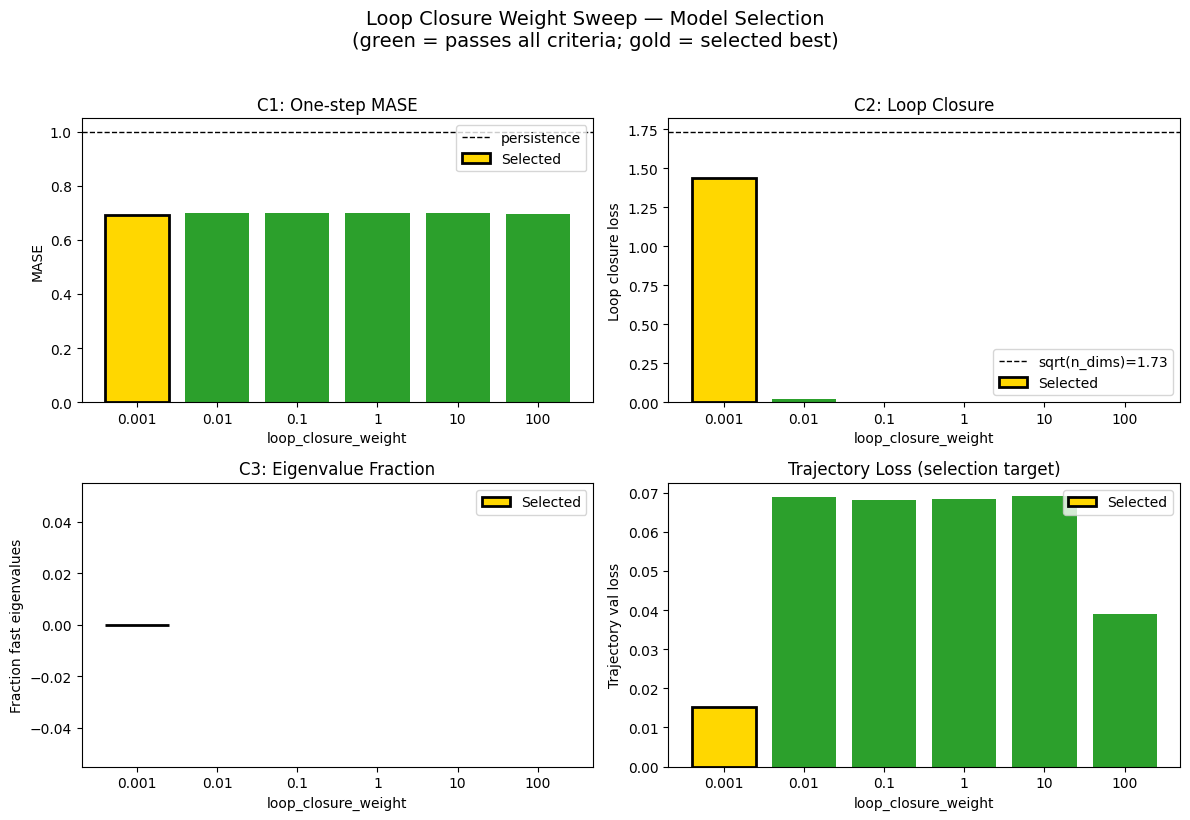

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases = [m.one_step_mase for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step MASE
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
if result.best_index is not None:
    axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 0].axhline(y=1.0, color='k', linestyle='--', lw=1, label='persistence')
axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels)
axes[0, 0].set_ylabel('MASE'); axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].legend()

# Panel 2: Loop closure loss
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
if result.best_index is not None:
    axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 1].axhline(y=np.sqrt(n_dims), color='k', linestyle='--', lw=1, label=f'sqrt(n_dims)={np.sqrt(n_dims):.2f}')
axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels)
axes[0, 1].set_ylabel('Loop closure loss'); axes[0, 1].set_title('C2: Loop Closure')
axes[0, 1].legend()

# Panel 3: Fast eigenvalue fraction
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
if result.best_index is not None:
    axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels)
axes[1, 0].set_ylabel('Fraction fast eigenvalues'); axes[1, 0].set_title('C3: Eigenvalue Fraction')
axes[1, 0].legend()

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels)
axes[1, 1].set_ylabel('Trajectory val loss'); axes[1, 1].set_title('Trajectory Loss (selection target)')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('loop_closure_weight')

fig.suptitle(
    'Loop Closure Weight Sweep — Model Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 8. Load the Best Model for Downstream Use

In [37]:
best_run_id = sweep_run_ids[result.best_index]
best_lambda = sweep_lambdas[result.best_index]

print(f"Loading best model: run_id={best_run_id}, lambda={best_lambda}")

run, best_cfg, eq, dt, values, _, _, _, _, best_lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# Rebuild dataloaders from the loaded data
train_dl, val_dl, test_dl, trajs = create_dataloaders(best_cfg, values, verbose=True, return_full_obs=True)

print(f"\nModel type: {type(best_lit_model).__name__}")
print(f"Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}")

Loading best model: run_id=fpll4j7o, lambda=0.001
Using cached pretrained encoder.


Sequence Indices:   0%|          | 0/1058 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23276, 100, 43])
Validation dataset shape: torch.Size([7406, 100, 43])
Test dataset shape: torch.Size([3174, 100, 43])
Train trajectories dataset shape: torch.Size([22, 1158, 43])
Validation trajectories dataset shape: torch.Size([7, 1158, 43])
Test trajectories dataset shape: torch.Size([3, 1158, 43])

Model type: LitLatentJacobianODE
Total params: 7,539,481


### 8a. Lyapunov Exponent Comparison (Best Model)

Predicted Lyapunov exponents (best model):
  lambda_1 = +0.7461
  lambda_2 = +0.6889
  lambda_3 = +0.3720
  lambda_4 = +0.2041
  lambda_5 = +0.0794
  lambda_6 = -0.1800
  lambda_7 = -0.2139
  lambda_8 = -0.3219
  lambda_9 = -0.5857
  lambda_10 = -1.0197

True Lorenz:
  lambda_1 = +0.9100
  lambda_2 = +0.0000
  lambda_3 = -14.5700


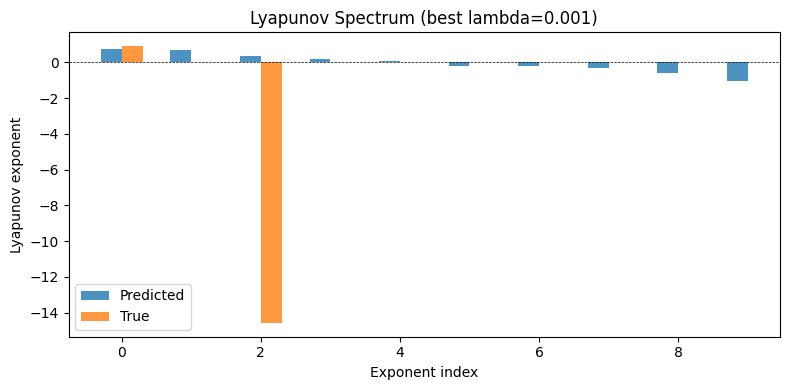

In [38]:
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

best_lit_model.eval()
with torch.no_grad():
    test_batch = next(iter(test_dl))
    if isinstance(test_batch, (list, tuple)):
        test_batch = test_batch[0]
    z_test = best_lit_model.encode_trajectory(test_batch)
    z_long = z_test[:5].reshape(-1, z_test.shape[-1]).unsqueeze(0)
    jacs_long = best_lit_model.compute_jacobians(z_long)[0]
    pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_long, dt)

print("Predicted Lyapunov exponents (best model):")
for i, le in enumerate(pred_lyap):
    print(f"  lambda_{i+1} = {le.item():+.4f}")
print(f"\nTrue Lorenz:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  lambda_{i+1} = {le:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
pred_np = pred_lyap.numpy()
ax.bar(np.arange(len(pred_np)) - 0.15, pred_np, width=0.3, label="Predicted", alpha=0.8)
ax.bar(np.arange(len(TRUE_LYAPUNOV)) + 0.15, TRUE_LYAPUNOV, width=0.3, label="True", alpha=0.8)
ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum (best lambda={best_lambda})")
ax.legend()
plt.tight_layout()
plt.show()